<a href="https://colab.research.google.com/github/vanesamrd/PCVK_Ganjil_2026/blob/main/P5_25_Vanesa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Vanesa Mardiana Putri'
NIM  = '244107020129'

N = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA  :', NAMA)
print('NIM   :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA  : Vanesa Mardiana Putri
NIM   : 244107020129 | N = 129
bins   : 16
clip   : 3.0
tile   : 3
L      : 2
WAKTU : 2026-09-22 12:30:32 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : ae25fb968dee7813


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math, os, glob

CONTOH = '/content/drive/MyDrive/pcvk_vanesa/Images'
BASE   = '/content/drive/MyDrive/pcvk_vanesa/Images/' + NIM

Mounted at /content/drive


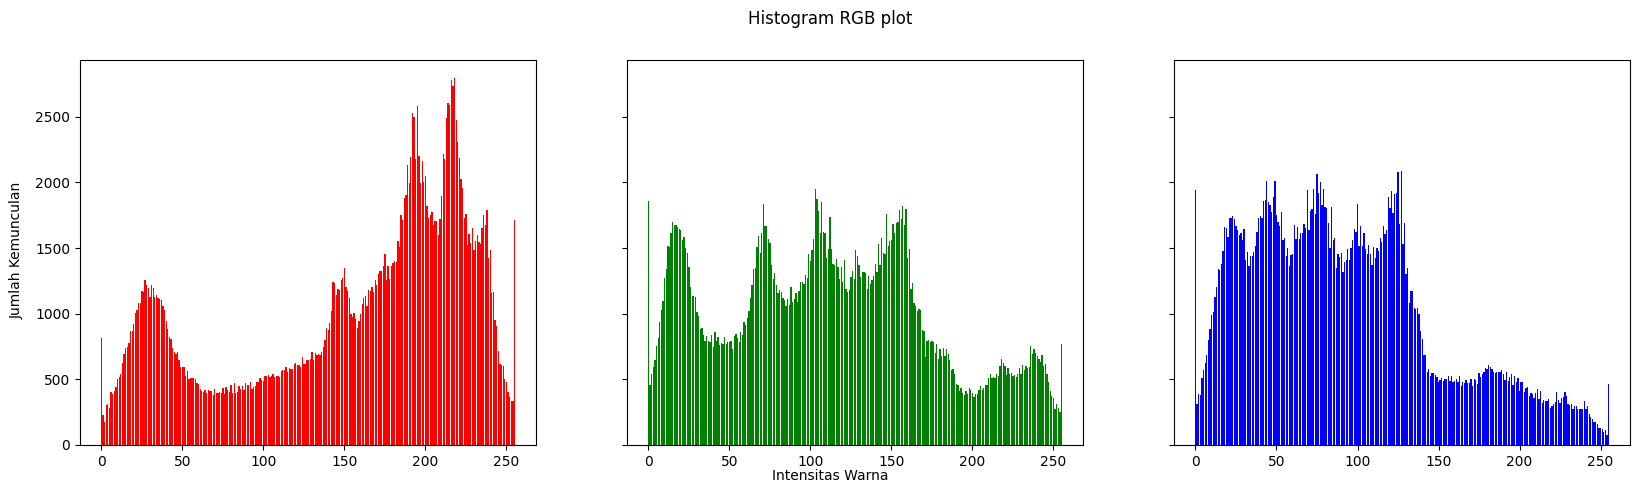

In [5]:
img = cv.imread(CONTOH + '/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red   = [0]*256
green = [0]*256
blue  = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]]   += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]]  += 1

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

In [6]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

def cek_selisih(nama_file):
    gray = cv.imread(nama_file, cv.IMREAD_GRAYSCALE)
    h_manual = histogram_manual(gray)
    h_numpy, _ = np.histogram(gray, bins=256, range=(0,256))
    h_cv = cv.calcHist([gray], [0], None, [256], [0,256]).flatten()

    selisih_np_manual = np.max(np.abs(h_manual - h_numpy))
    selisih_cv_manual = np.max(np.abs(h_manual - h_cv))
    print(nama_file)
    print('Selisih maksimum manual vs numpy   :', selisih_np_manual)
    print('Selisih maksimum manual vs cv.calcHist:', selisih_cv_manual)

cek_selisih(CONTOH + '/lena.jpg')
cek_selisih(BASE + '/KTM1b.jpg')

/content/drive/MyDrive/pcvk_vanesa/Images/lena.jpg
Selisih maksimum manual vs numpy   : 0
Selisih maksimum manual vs cv.calcHist: 0.0
/content/drive/MyDrive/pcvk_vanesa/Images/244107020129/KTM1b.jpg
Selisih maksimum manual vs numpy   : 0
Selisih maksimum manual vs cv.calcHist: 0.0


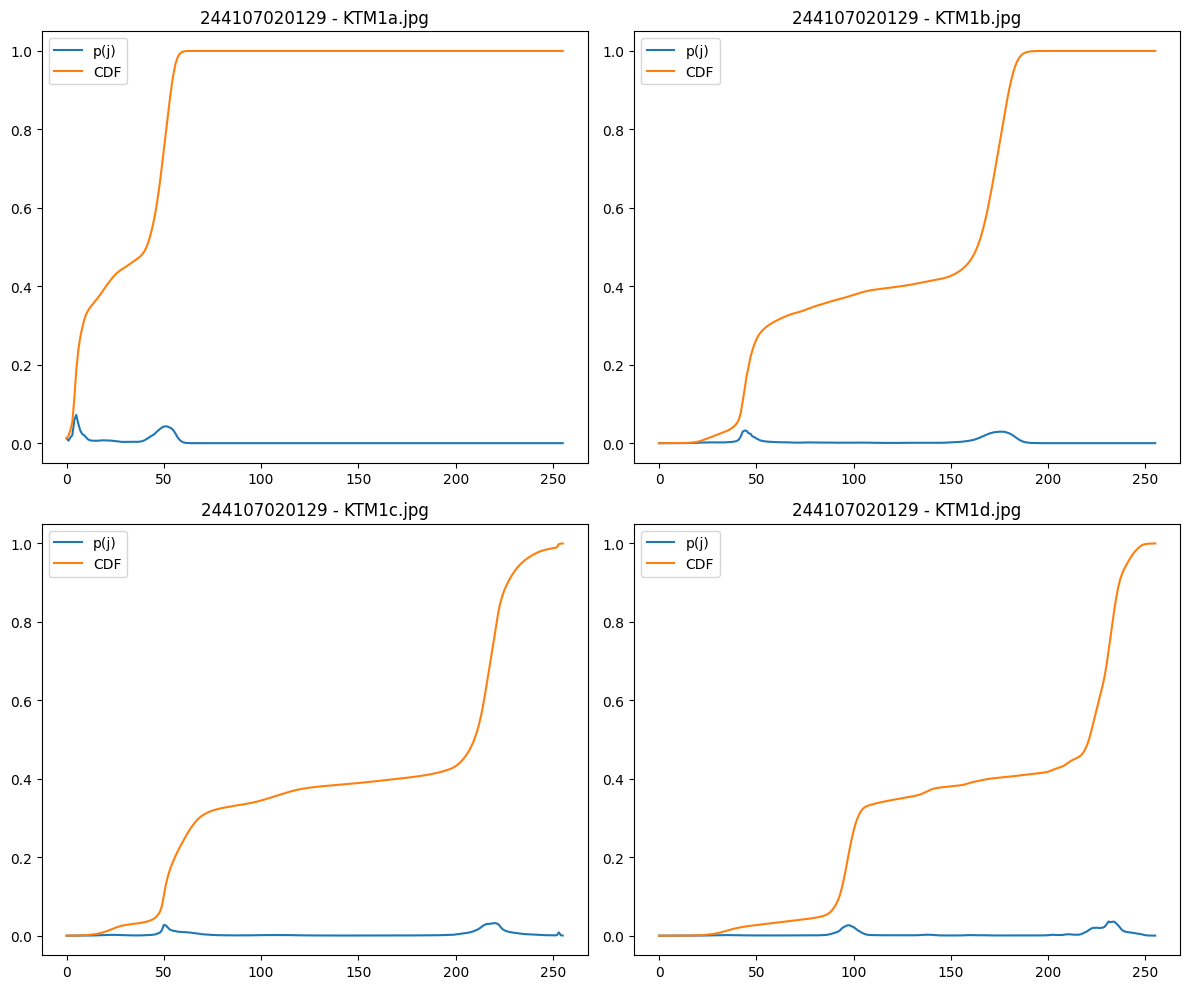

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(12,10))
nama_file = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']

for ax, nf in zip(axs.flat, nama_file):
    gray = cv.imread(BASE + '/' + nf, cv.IMREAD_GRAYSCALE)
    h = histogram_manual(gray)
    p = h / gray.size
    cdf = np.cumsum(p)
    ax.plot(p, label='p(j)')
    ax.plot(cdf, label='CDF')
    ax.set_title(NIM + ' - ' + nf)
    ax.legend()

plt.tight_layout()
plt.show()

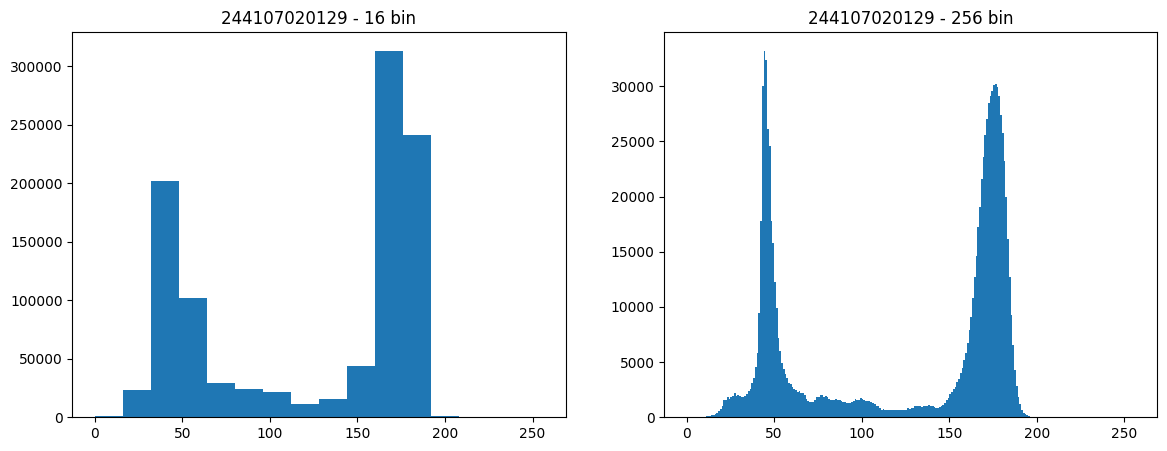

In [8]:
gray = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

fig, axs = plt.subplots(1, 2, figsize=(14,5))
axs[0].hist(gray.ravel(), bins=PARAM['bins'], range=(0,256))
axs[0].set_title(NIM + f" - {PARAM['bins']} bin")
axs[1].hist(gray.ravel(), bins=256, range=(0,256))
axs[1].set_title(NIM + " - 256 bin")
plt.show()

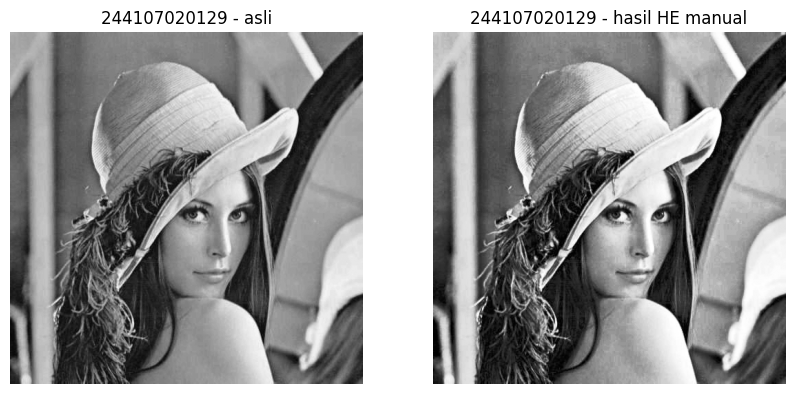

In [9]:
def histogram_equalization_manual(gray):
    L = 256
    h = histogram_manual(gray, L)
    p = h / gray.size
    cdf = np.cumsum(p)
    Ko = np.round(cdf * (L - 1)).astype(np.uint8)   # rumus G(zq)
    hasil = Ko[gray]
    return hasil

gray = cv.imread(CONTOH + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
hasil = histogram_equalization_manual(gray)

fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(gray, cmap='gray'); axs[0].set_title(NIM + ' - asli'); axs[0].axis('off')
axs[1].imshow(hasil, cmap='gray'); axs[1].set_title(NIM + ' - hasil HE manual'); axs[1].axis('off')
plt.show()

In [10]:
def bandingkan_he(nama_file):
    gray = cv.imread(nama_file, cv.IMREAD_GRAYSCALE)
    manual = histogram_equalization_manual(gray)
    cv_hasil = cv.equalizeHist(gray)
    selisih = np.max(np.abs(manual.astype(int) - cv_hasil.astype(int)))
    print(nama_file, '-> selisih maksimum:', selisih)

bandingkan_he(CONTOH + '/lena_lc.jpg')
bandingkan_he(BASE + '/KTM1a.jpg')

/content/drive/MyDrive/pcvk_vanesa/Images/lena_lc.jpg -> selisih maksimum: 0
/content/drive/MyDrive/pcvk_vanesa/Images/244107020129/KTM1a.jpg -> selisih maksimum: 4


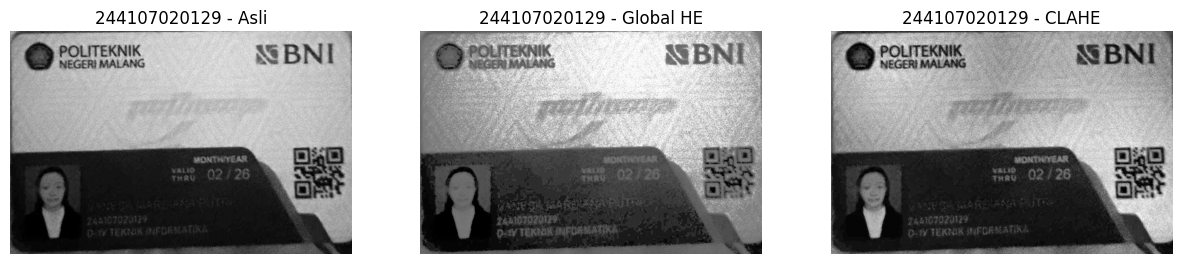

In [11]:
gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe = clahe.apply(gray)
hasil_global = cv.equalizeHist(gray)

fig, axs = plt.subplots(1, 3, figsize=(15,5))
for ax, im, judul in zip(axs, [gray, hasil_global, hasil_clahe], ['Asli', 'Global HE', 'CLAHE']):
    ax.imshow(im, cmap='gray'); ax.set_title(NIM + ' - ' + judul); ax.axis('off')
plt.show()

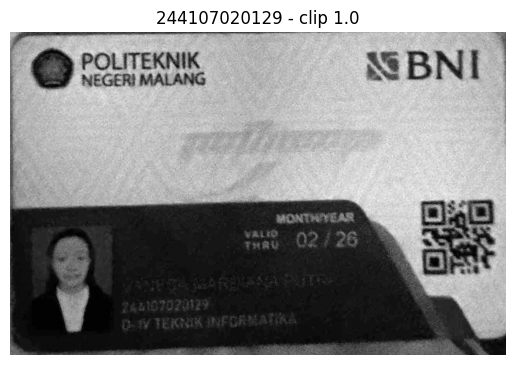

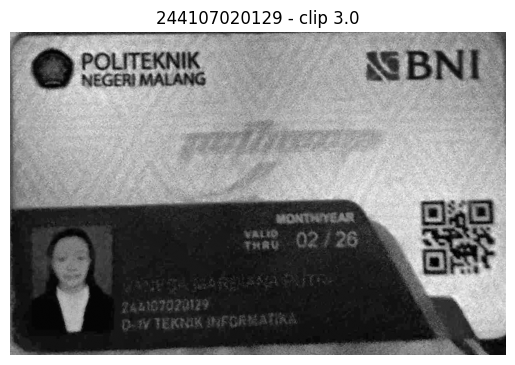

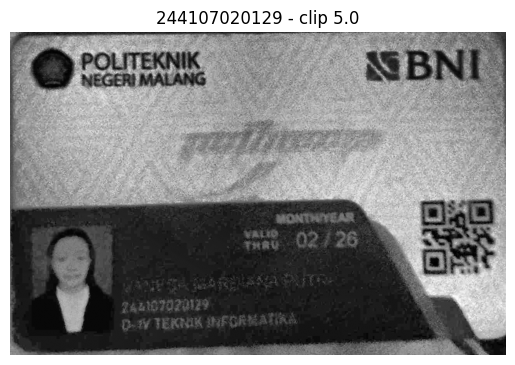

In [12]:
for c in [1.0, PARAM['clip'], 5.0]:
    clahe = cv.createCLAHE(clipLimit=c, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil = clahe.apply(gray)
    plt.figure()
    plt.imshow(hasil, cmap='gray'); plt.title(NIM + f' - clip {c}'); plt.axis('off')
    plt.show()

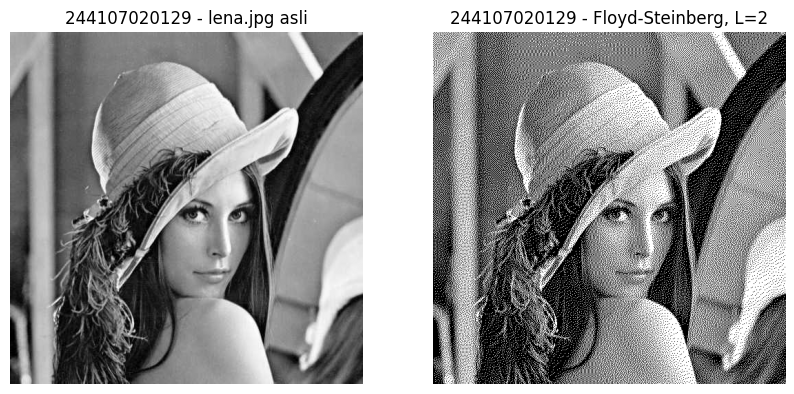

In [13]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                     img[y,   x+1] += error * 7 / 16
            if x > 0 and y+1 < H:              img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                      img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y+1 < H:          img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

gray = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)
hasil = floyd_steinberg(gray, L=2)

fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(gray, cmap='gray'); axs[0].set_title(NIM + ' - lena.jpg asli'); axs[0].axis('off')
axs[1].imshow(hasil, cmap='gray'); axs[1].set_title(NIM + ' - Floyd-Steinberg, L=2'); axs[1].axis('off')
plt.show()

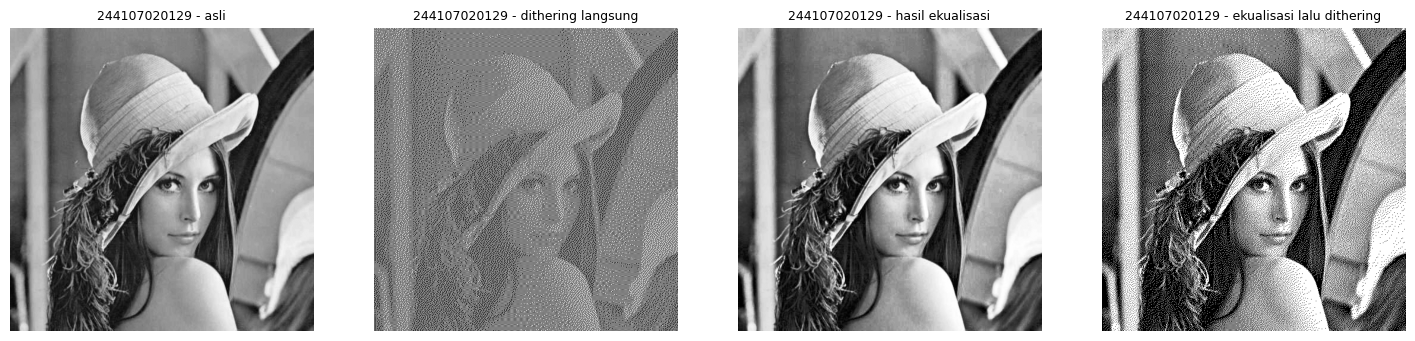

In [ ]:
def proses_bandingan(nama_file, L):
    gray = cv.imread(nama_file, cv.IMREAD_GRAYSCALE)
    dith_langsung = floyd_steinberg(gray, L)
    he = cv.equalizeHist(gray)
    dith_he = floyd_steinberg(he, L)

    fig, axs = plt.subplots(1, 4, figsize=(18,5))
    for ax, im, judul in zip(axs, [gray, dith_langsung, he, dith_he],
                              ['asli', 'dithering langsung', 'hasil ekualisasi', 'ekualisasi lalu dithering']):
        ax.imshow(im, cmap='gray'); ax.set_title(NIM + ' - ' + judul, fontsize=9); ax.axis('off')
    plt.show()

proses_bandingan(CONTOH + '/lena_lc.jpg', PARAM['L'])
proses_bandingan(BASE + '/KTM1a.jpg', PARAM['L'])